In [1]:
import torch
from diffusers import DDPMPipeline
from matplotlib import pyplot as plt
from torchvision.utils import make_grid

In [2]:
# Set the device to use our GPU or CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
# Load the pipeline
image_pipe = DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")
image_pipe.to(device)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Couldn't connect to the Hub: (MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /api/models/google/ddpm-celebahq-256 (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x000001EFC6B78AD0>, 'Connection to huggingface.co timed out. (connect timeout=None)'))"), '(Request ID: fa139303-0319-4c0d-88c4-8c84470f79ea)').
Will try to load from local cache.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\csn\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\csn\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "google/ddpm-celebahq-256",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

  0%|          | 0/1000 [00:00<?, ?it/s]

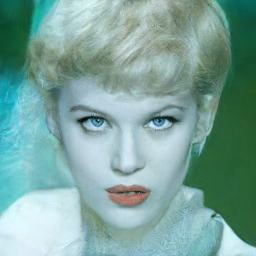

In [5]:
images = image_pipe().images
images[0]

In [ ]:
def plot_noise_and_denoise(scheduler_output, step):
    _, axs = plt.subplots(1, 2, figsize=(12, 5))
    prev_prev_sample = scheduler_output.prev_sample
    grid = make_grid(prev_prev_sample, nrow=4).permute(1, 2, 0)
    axs[0].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
    axs[0].set_title(f"Current x (step {step})")
    axs[0].axis("off")

    pred_x0 = scheduler_output.pred_original_sample
    grid = make_grid(pred_x0, nrow=4).permute(1, 2, 0)
    axs[1].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
    axs[1].set_title(f"Predicted denoised images (step {step})")
    axs[1].axis("off")
    plt.show()

In [ ]:
# 随机起始点是4张图像 每张图像都是3通道（RGB）、256x256像素的图像
image = torch.randn(4, 3, 256, 256).to(device)
# 设置特定的扩散步骤数量
image_pipe.scheduler.set_timesteps(num_inference_steps=30)
for i, t in enumerate(image_pipe.scheduler.timesteps):
# 根据当前样本x和时间步t获取预测结果
    with torch.inference_mode():
# 我们需要传入时间步t，以便模型知道它当前处于哪个时间步。
        noise_pred = image_pipe.unet(image, t)["sample"]
# 计算使用调度器后更新后的x
    scheduler_output = image_pipe.scheduler.step(noise_pred, t, image)
# 更新x
    image = scheduler_output.prev_sample
# 同时展示x和预测的去噪图像
    if i % 10 == 0 or i == len(image_pipe.scheduler.timesteps) - 1:
        plot_noise_and_denoise(scheduler_output, i)